<a href="https://colab.research.google.com/github/yeshaa23/Project-A-Kelompok-4-Pertamina-PBAGenap/blob/main/Notebook/4_POS_NER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Persiapan

In [ ]:
# ==============================
# Install Library
# ==============================
!pip install stanza tqdm matplotlib seaborn transformers torch
!pip install tqdm

In [ ]:
# ==============================
# Import Library
# ==============================
import pandas as pd
import stanza
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline
from IPython.display import display, HTML
from collections import Counter, defaultdict
import ast

In [ ]:
# ==============================
# Mount Google Drive
# ==============================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import os

# ==============================
# Load Dataset
# ==============================
file_path = '/content/drive/MyDrive/ProjectA-PBA/hasil_preprocessing_pertamina.csv'  # ganti sesuai folder
df = pd.read_csv(file_path)

df['final_text_stemmed'] = df['final_text_stemmed'].fillna("").astype(str)
print(df.head())

                                                Link  \
0  https://money.kompas.com/image/2017/10/03/1815...   
1  https://money.kompas.com/read/2016/06/06/14280...   
2  https://money.kompas.com/read/2017/02/03/12195...   
3  https://money.kompas.com/read/2016/05/27/20434...   
4  https://money.kompas.com/read/2017/03/24/11200...   

                                               Judul  \
0  Foto : CSR Pertamina Lubricants Kini Fokus ke ...   
1  Gandeng Dua Bank, Pertamina Lubricants Yakin P...   
2  Dua Pucuk Pimpinan Pertamina Dicopot, Yenni An...   
3  Ini yang Dilakukan PTKAM untuk Efisiensi 'Oil ...   
4  Ini Tugas Pertama Adiatma Sardjito Sebagai Jub...   

                                          Isi Berita   Status  \
0  Diskusi mengenai CSR di industri pelumas berta...  success   
1  JAKARTA, KOMPAS.com - Anak perusahaan Pertamin...  success   
2  JAKARTA, KOMPAS.com — Pasca-pencopotan dua puc...  success   
3  JAKARTA, KOMPAS.com - PT Pertamina (persero) t...  success   
4

In [ ]:
# ==============================
# Download & Load Stanza (POS)
# ==============================
stanza.download('id')
nlp = stanza.Pipeline(lang='id', processors='tokenize,pos')

INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/resources.json
INFO:stanza:Downloading default packages for language: id (Indonesian) ...
INFO:stanza:File exists: /root/.cache/stanza/1.11.0/resources/id/default.zip
INFO:stanza:Finished downloading models and saved to /root/.cache/stanza/1.11.0/resources
INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/resources.json
INFO:stanza:Loading these models for language: id (Indonesian):
| Processor | Package    |
--------------------------
| tokenize  | gsd        |
| mwt       | gsd        |
| pos       | gsd_charlm |

INFO:stanza:Using device: cuda
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Done loading processors!


In [ ]:
# ==============================
# POS Tagging
# ==============================
def pos_tagging(text):
    if not isinstance(text, str) or text.strip() == "":
        return []
    doc = nlp(text)
    tokens_pos = []
    for sent in doc.sentences:
        for word in sent.words:
            tokens_pos.append((word.text, word.pos))
    return tokens_pos

tqdm.pandas()
df['POS'] = df['final_text_stemmed'].progress_apply(pos_tagging)

100%|██████████| 1883/1883 [12:38<00:00,  2.48it/s]


In [ ]:
# ==============================
# Expand POS ke Tabel per Token
# ==============================
df = df.reset_index(drop=True)

# Expand POS ke tabel per token
rows = []
for idx, row in df.iterrows():
    for word, pos in row['POS']:
        rows.append({
            'content_id': idx,  # idx sekarang 0,1,2,... sesuai baris
            'word': word,
            'pos': pos
        })
df_detail = pd.DataFrame(rows)
df_detail

,content_id,word,pos
0,0,diskusi,NOUN
1,0,kena,NOUN
2,0,csr,NOUN
3,0,industri,NOUN
4,0,lumas,NOUN
...,...,...,...
478990,1881,situs,NOUN
478991,1881,web,NOUN
478992,1881,izin,NOUN
478993,1881,tulis,NOUN


In [ ]:
# ==============================
# Visualisasi POS Warna-warni (sample baris ke-8)
# ==============================
from IPython.display import HTML, display

pos_colors = {
    'NOUN':  '#8ED1E8',   # pastel biru
    'VERB':  '#F77878',   # pastel coral
    'ADJ':   '#B7E48A',   # pastel hijau muda
    'ADV':   '#C8B6F2',   # pastel ungu
    'PROPN': '#84B9E8',   # pastel biru langit
    'PRON':  '#F6D1DC',   # pastel pink muda
    'ADP':   '#F3E55B',   # pastel kuning
    'DET':   '#F3C38C',   # pastel peach
    'CONJ':  '#6FA8E8',   # pastel biru
    'SCONJ': '#E7B7D8',   # pastel pink-lilac
    'AUX':   '#F6AE61',   # pastel orange
    'PUNCT': '#E6E3DF',   # abu lembut
    'NUM':   '#F7B6D2',   # pink pastel
    'PART':  '#98E2CF',   # mint pastel
    'INTJ':  '#FFD966',   # kuning hangat
    'SYM':   '#D9D9D9',   # abu muda
    'X':     '#D6CDEA'    # lavender abu
}

sample_text = df['final_text_clean'].iloc[6]
doc = nlp(sample_text)

html = "<div style='line-height: 2.5; font-family: Arial, sans-serif;'>"

for sent in doc.sentences:
    for token in sent.words:
        color = pos_colors.get(token.pos, "#E6E3DF")
        html += f"""
        <span style="
            background-color:{color};
            color:#333333;
            padding:6px 10px;
            margin:3px;
            border-radius:16px;
            display:inline-block;
            font-size:14px;
        ">
            {token.text} <strong>{token.pos}</strong>
        </span>
        """

html += "</div>"
display(HTML(html))

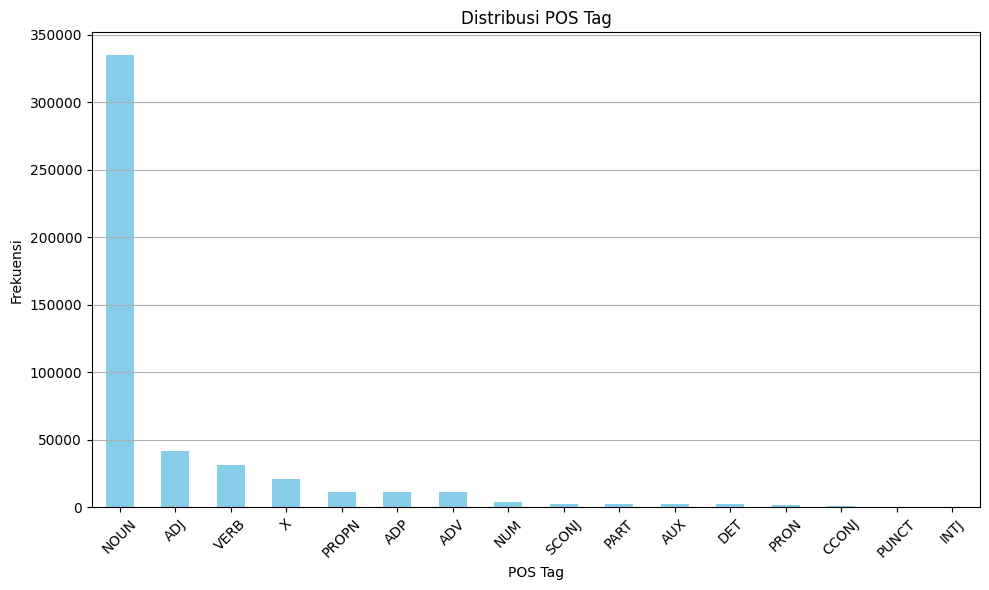

In [ ]:
# ==============================
# Bar Chart Distribusi POS
# ==============================
pos_counts = df_detail['pos'].value_counts()
plt.figure(figsize=(10,6))
pos_counts.plot(kind='bar', color='skyblue')
plt.title("Distribusi POS Tag")
plt.xlabel("POS Tag")
plt.ylabel("Frekuensi")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# Hitung frekuensi tiap POS
pos_counts = df_detail['pos'].value_counts().reset_index()
pos_counts.columns = ['POS Tag', 'Frekuensi']

# Tampilkan tabel
pos_counts

,POS Tag,Frekuensi
0,NOUN,335163
1,ADJ,41943
2,VERB,31148
3,X,20657
4,PROPN,11498
5,ADP,11473
6,ADV,11430
7,NUM,4004
8,SCONJ,2387
9,PART,2300


In [ ]:
# ==============================
# Load IndoBERT untuk NER
# ==============================
MODEL_NAME = "cahya/bert-base-indonesian-NER"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForTokenClassification.from_pretrained(MODEL_NAME)
ner_pipeline = pipeline("ner", model=model, tokenizer=tokenizer, aggregation_strategy="simple")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: cahya/bert-base-indonesian-NER
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.pooler.dense.bias       | UNEXPECTED |  | 
bert.pooler.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# ==============================
# Fungsi NER
# ==============================
def run_ner(text):
    if not isinstance(text, str) or text.strip() == "":
        return []
    try:
        entities = ner_pipeline(text)
        formatted_entities = [{'entity': e['word'],'label': e['entity_group'],'start': e['start'],'end': e['end']} for e in entities]
        return formatted_entities
    except:
        return []

def merge_adjacent_entities(entities):
    if not entities:
        return []
    entities = sorted(entities, key=lambda e: e['start'])
    merged = []
    current_entity = dict(entities[0])
    for next_entity in entities[1:]:
        next_entity = dict(next_entity)
        if next_entity['start'] <= current_entity['end'] + 1 and next_entity['label'] == current_entity['label']:
            current_entity['entity'] += " " + next_entity['entity']
            current_entity['end'] = next_entity['end']
        else:
            merged.append(current_entity)
            current_entity = next_entity
    merged.append(current_entity)
    return merged

RELEVANT_LABELS = {'ORG','LOC','PER','GPE','FAC','DAT','TIM','EVT','NOR','LAW','PRD'}
def filter_relevance_and_clean_entities(entities):
    corrected = []
    EXCLUDE_PRD = {'bus','truk','rem','rem blong','video','gambas','tj','lrt','mrt','transjakarta'}
    NOISE_ENTITIES = {'SCROLL','CONTENT','TENT','EVT','TO','CONTIN'}
    for e in entities:
        label = e['label']
        text_lower = e['entity'].lower().strip()
        if e['entity'].upper() in NOISE_ENTITIES: continue
        if label not in RELEVANT_LABELS: continue
        if label == 'PRD' and text_lower in EXCLUDE_PRD:
            if text_lower in ('mrt','lrt','transjakarta','tj'): e['label'] = 'ORG'
            else: continue
        cleaned_text = e['entity'].replace('##','').strip()
        if len(cleaned_text) <= 1: continue
        e['entity'] = cleaned_text
        corrected.append(e)
    return corrected

In [ ]:
# ==============================
# Terapkan NER ke Dataset
# ==============================
tqdm.pandas()
df['NER_Raw'] = df['final_text_stemmed'].progress_apply(run_ner)
df['NER_Fused'] = df['NER_Raw'].apply(merge_adjacent_entities)
df['NER_Final'] = df['NER_Fused'].apply(filter_relevance_and_clean_entities)

100%|██████████| 1883/1883 [00:54<00:00, 34.47it/s]


In [ ]:
# ==============================
# Expand NER ke Tabel Per Entitas
# ==============================
rows = []
for idx, row in df.iterrows():
    for ent in row['NER_Final']:
        rows.append({'content_id': idx,'entity': ent['entity'],'label': ent['label']})
df_ner_detail = pd.DataFrame(rows)
df_ner_detail

,content_id,entity,label
0,0,kena cs,EVT
1,0,industri lum,EVT
2,0,as,ORG
3,0,format komunikasi elegan,EVT
4,0,selasa,DAT
...,...,...,...
84995,1881,ke sinaga,PRD
84996,1881,yunianto,PRD
84997,1881,crawling indeks,PRD
84998,1881,web izin,PRD


In [ ]:
# ==============================
# Visualisasi NER
# ==============================
ner_colors = {
    'PER':'#ffb3ba',  # pastel pink
    'ORG':'#bae1ff',  # pastel biru
    'LOC':'#baffc9',  # pastel hijau
    'GPE':'#98E2CF',  # pastel mint
    'FAC':'#ffd699',  # pastel orange
    'DAT':'#fffdbA',  # pastel kuning
    'TIM':'#C8B6F2',  # pastel ungu
    'EVT':'#dcd3ff',  # pastel lavender
    'NOR':'#f7c5cc',  # pastel merah muda
    'LAW':'#F6AE61',  # pastel orange muda
    'PRD':'#F3C38C'   # pastel peach
}

# Sample baris (misal baris ke-7)
sample_text = df['final_text_stemmed'].iloc[6]
entities = df['entities'].iloc[6]

html = "<div style='line-height:2.5; font-family:Arial;'>"

for word, pos_or_entity in zip(sample_text.split(), [None]*len(sample_text.split())):
    # Cari apakah kata ini ada di entities
    matched = [ent for ent in entities if ent[0] == word]
    if matched:
        label = matched[0][1]
        color = ner_colors.get(label,'#dddddd')
        html += f"<span style='background-color:{color}; padding:6px 10px; margin:3px; border-radius:16px; display:inline-block'>{word} <strong>{label}</strong></span>"
    else:
        html += f"<span style='padding:6px 10px; margin:3px; display:inline-block'>{word}</span>"

html += "</div>"
display(HTML(html))

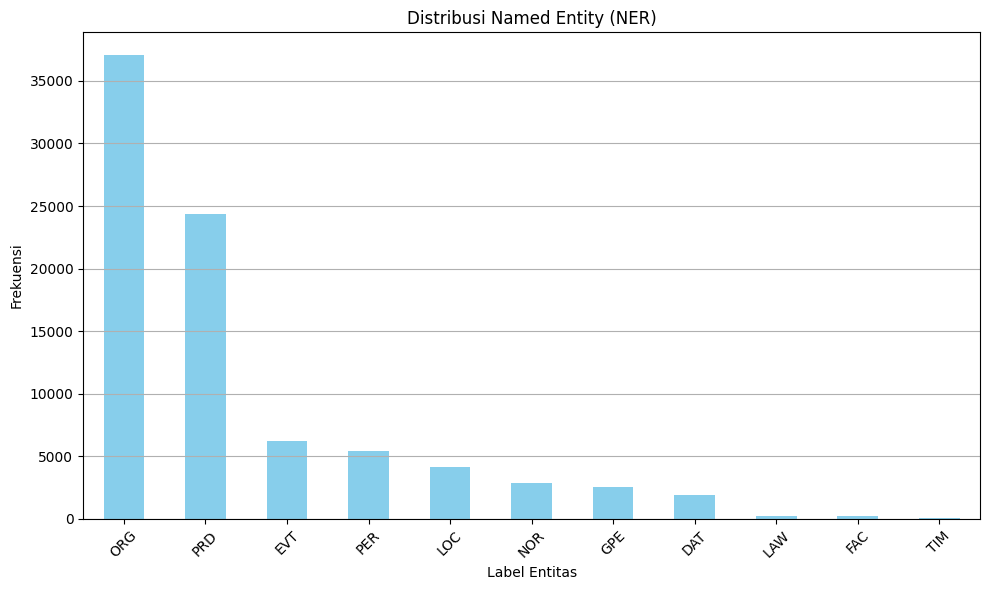

In [ ]:
# ==============================
# Bar Chart Distribusi NER
# ==============================
ner_counts = df_ner_detail['label'].value_counts()
plt.figure(figsize=(10,6))
ner_counts.plot(kind='bar', color='skyblue')
plt.title("Distribusi Named Entity (NER)")
plt.xlabel("Label Entitas")
plt.ylabel("Frekuensi")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
df

,Link,Judul,Isi Berita,Status,Tag,Sentimen,Penerbit,final_text_clean,final_text_stemmed,jumlah_token_before_sw,jumlah_token_after_sw,POS,entities,NER_Raw,NER_Fused,NER_Final
0,https://money.kompas.com/image/2017/10/03/1815...,Foto : CSR Pertamina Lubricants Kini Fokus ke ...,Diskusi mengenai CSR di industri pelumas berta...,success,Ekonomi,Neutral,Kompas,diskusi mengenai csr industri pelumas bertajuk...,diskusi kena csr industri lumas tajuk cari for...,16,13,"[(diskusi, NOUN), (kena, NOUN), (csr, NOUN), (...","[(kena cs, EVT), (##r, ORG), (industri lum, EV...","[{'entity': 'kena cs', 'label': 'EVT', 'start'...","[{'entity': 'kena cs', 'label': 'EVT', 'start'...","[{'entity': 'kena cs', 'label': 'EVT', 'start'..."
1,https://money.kompas.com/read/2016/06/06/14280...,"Gandeng Dua Bank, Pertamina Lubricants Yakin P...","JAKARTA, KOMPAS.com - Anak perusahaan Pertamin...",success,Kecelakaan Kerja,Positive,Kompas,jakarta kompas com anak perusahaan pertamina y...,anak usaha pertamina pertamina lubricants gand...,130,95,"[(anak, NOUN), (usaha, NOUN), (pertamina, NOUN...","[(pertamina pertamina lubricants, ORG), (bank ...","[{'entity': 'pertamina pertamina lubricants', ...","[{'entity': 'pertamina pertamina lubricants', ...","[{'entity': 'pertamina pertamina lubricants', ..."
2,https://money.kompas.com/read/2017/02/03/12195...,"Dua Pucuk Pimpinan Pertamina Dicopot, Yenni An...","JAKARTA, KOMPAS.com — Pasca-pencopotan dua puc...",success,Migas,Positive,Kompas,jakarta kompas com pasca pencopotan dua pucuk ...,pasca copot pucuk pimpin pertamina menteri bad...,145,120,"[(pasca, ADP), (copot, NOUN), (pucuk, NOUN), (...","[(pertamina, ORG), (menteri badan usaha milik ...","[{'entity': 'pertamina', 'label': 'ORG', 'star...","[{'entity': 'pertamina', 'label': 'ORG', 'star...","[{'entity': 'pertamina', 'label': 'ORG', 'star..."
3,https://money.kompas.com/read/2016/05/27/20434...,Ini yang Dilakukan PTKAM untuk Efisiensi 'Oil ...,"JAKARTA, KOMPAS.com - PT Pertamina (persero) t...",success,Gangguan Operasional,Positive,Kompas,jakarta kompas com pertamina persero telah mem...,pertamina bentuk buah program mengefesiensikan...,174,121,"[(pertamina, NOUN), (bentuk, NOUN), (buah, NOU...","[(pertamina, ORG), (minyak oil losses, PRD), (...","[{'entity': 'pertamina', 'label': 'ORG', 'star...","[{'entity': 'pertamina', 'label': 'ORG', 'star...","[{'entity': 'pertamina', 'label': 'ORG', 'star..."
4,https://money.kompas.com/read/2017/03/24/11200...,Ini Tugas Pertama Adiatma Sardjito Sebagai Jub...,"JAKARTA, KOMPAS.com - Adiatma Sardjito telah r...",success,Migas,Positive,Kompas,jakarta kompas com adiatma sardjito telah resm...,adiatma sardjito resmi angkat corporate commun...,193,134,"[(adiatma, PROPN), (sardjito, PROPN), (resmi, ...","[(adiatma sardjito, PER), (corporate communica...","[{'entity': 'adiatma sardjito', 'label': 'PER'...","[{'entity': 'adiatma sardjito', 'label': 'PER'...","[{'entity': 'adiatma sardjito', 'label': 'PER'..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1878,https://industri.kontan.co.id/news/pertamina-e...,Pertamina EP mulai pengeboran sumur eksplorasi...,ILUSTRASI. pengeboran minyak\n\nReporter: Ridw...,success,Migas,Positive,Kontan,ilustrasi pengeboran minyak reporter ridwan na...,bor minyak reporter ridwan nanda mulyana narit...,296,215,"[(bor, NOUN), (minyak, NOUN), (reporter, NOUN)...","[(bor minyak, ORG), (ridwan nanda mulyana nari...","[{'entity': 'bor minyak', 'label': 'ORG', 'sta...","[{'entity': 'bor minyak', 'label': 'ORG', 'sta...","[{'entity': 'bor minyak', 'label': 'ORG', 'sta..."
1879,https://www.tempo.co/ekonomi/titik-sumur-bor-p...,"Titik Sumur Bor Pertamina EP Terus Turun, Tahu...","TEMPO.CO, Jakarta - PT Pertamina EP (Eksploras...",success,Migas,Negative,Tempo,tempo jakarta pertamina eksplorasi dan produks...,pertamina eksplorasi produksi sebut jumlah sum...,340,229,"[(pertamina, NOUN), (eksplorasi, NOUN), (produ...","[(pertamina, ORG), (sumur bor, PRD), (minyak k...","[{'entity': 'perta

In [ ]:
import string
from nltk.corpus import stopwords
import nltk

# Download stopwords NLTK (kalau belum)
nltk.download('stopwords')

# Stopwords bahasa Inggris + Indonesia
stopwords_eng = set(stopwords.words('english'))
stopwords_id = set(stopwords.words('indonesian'))

# Gabungkan & lowercase
all_stopwords = stopwords_eng.union(stopwords_id)
all_stopwords = {w.lower() for w in all_stopwords}

# List tanda baca
punctuation_list = list(string.punctuation)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:

# ===========================
# POS Filtered
# ===========================
df_filtered = df_detail[
    (~df_detail['word'].isin(punctuation_list)) &  # Bukan tanda baca
    (~df_detail['word'].str.lower().isin(all_stopwords))  # Bukan stopwords
]

# Hitung frekuensi (word, pos)
top_filtered = (
    df_filtered.groupby(['word','pos'])
    .size()
    .reset_index(name='count')
    .sort_values(by='count', ascending=False)
)

print("Top 20 POS words (filtered):")
print(top_filtered.head(20))

Top 20 POS words (filtered):
             word   pos  count
15353   pertamina  NOUN  13461
2046          bbm  NOUN   3726
10956        laku  NOUN   3541
22004       usaha  NOUN   3052
10048       kerja  NOUN   2797
19506        spbu  NOUN   2672
7542        harga  NOUN   2582
12950      minyak  NOUN   2385
6838          gas  NOUN   2344
5731       energi  NOUN   2339
1705        bakar  NOUN   2266
12883       milik  NOUN   1946
12287  masyarakat  NOUN   1939
10206      kilang  NOUN   1780
11502       liter  NOUN   1629
8970        jalan  NOUN   1623
21152     tingkat  NOUN   1583
16284     program  NOUN   1567
22038       utama   ADJ   1479
1664        bahan  NOUN   1433


In [ ]:
# ===========================
# NER Frequency
# ===========================
top_ner = (
    df_ner_detail.groupby(['entity','label'])
    .size()
    .reset_index(name='count')
    .sort_values(by='count', ascending=False)
)

print("\nTop 10 Named Entities:")
top_ner.head(10)


Top 10 Named Entities:


,entity,label,count
22858,pertamina,ORG,5354
3748,bbm,PRD,1670
29050,sp,PRD,538
19238,minyak,PRD,414
29075,spbu,PRD,269
28922,solar,PRD,243
17400,liter,PRD,233
17650,lp,ORG,224
9958,gas,PRD,219
22860,pertamina,PRD,215


In [ ]:
# ==============================
# Simpan CSV Final POS + NER
# ==============================
output_file = '/content/drive/MyDrive/ProjectA-PBA/hasil_POS_NER_final.csv'
df.to_csv(output_file,index=False)
print(f"Hasil POS & NER Final disimpan di {output_file}")

Hasil POS & NER Final disimpan di /content/drive/MyDrive/ProjectA-PBA/hasil_POS_NER_final.csv
